[Text(0, 0, 'Vis_1'),
 Text(0, 5, 'Vis_6'),
 Text(0, 10, 'Vis_11'),
 Text(0, 15, 'SomMot_2'),
 Text(0, 20, 'SomMot_7'),
 Text(0, 25, 'SomMot_12'),
 Text(0, 30, 'DorsAttn_Post_1'),
 Text(0, 35, 'DorsAttn_Post_6'),
 Text(0, 40, 'DorsAttn_FEF_1'),
 Text(0, 45, 'SalVentAttn_ParOper_3'),
 Text(0, 50, 'SalVentAttn_PFCl_1'),
 Text(0, 55, 'Limbic_OFC_2'),
 Text(0, 60, 'Cont_Par_1'),
 Text(0, 65, 'Cont_PFCl_1'),
 Text(0, 70, 'Cont_pCun_1'),
 Text(0, 75, 'Default_Temp_3'),
 Text(0, 80, 'Default_Par_3'),
 Text(0, 85, 'Default_PFC_4'),
 Text(0, 90, 'Default_PFC_9'),
 Text(0, 95, 'Default_pCunPCC_1')]

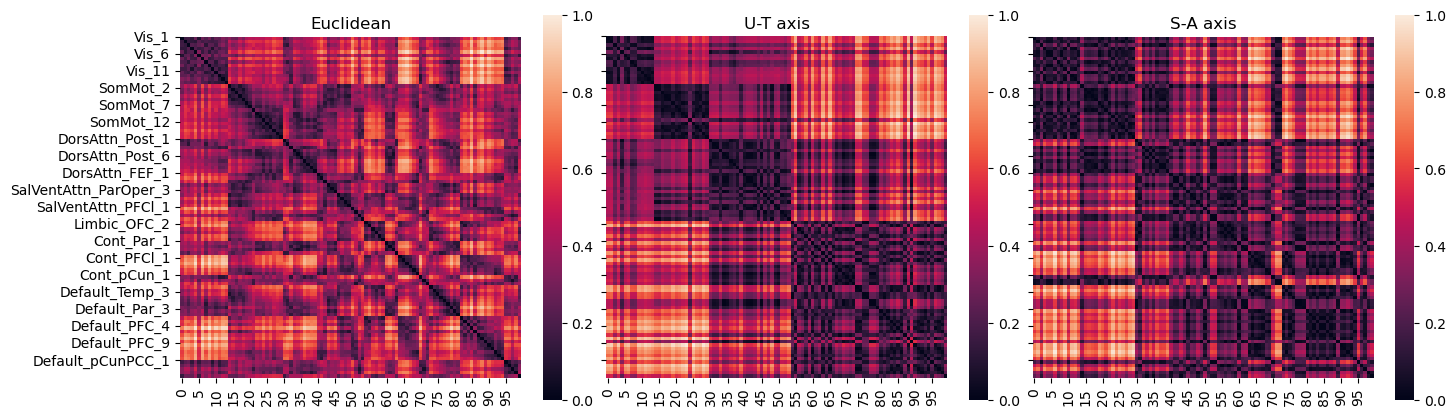

In [141]:
from src import utils
import numpy as np
from scipy.spatial import distance
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

maps = [
    [ 'Euclidean', '../data/schaefer200_centroids.csv' ],
    [ 'U-T axis',  '../data/schaefer200_ut-axis.npy'   ],
    [ 'S-A axis',  '../data/schaefer200_sa-axis.npy'   ],
]

n_maps = len(maps)

# euclidean
centroids = pd.read_csv(maps[0][1])[:100]
roi_names = centroids['ROI Name'].str.replace('7Networks_LH_','')
centroids.set_index("ROI Name", inplace=True)
brain_map = centroids.to_numpy()
maps[0].append(utils.normalize_x(utils.get_brainmap_distance(brain_map)))

# s-a axis
brain_map = np.load(maps[1][1])[:100]
maps[1].append(utils.normalize_x(utils.get_brainmap_distance(brain_map)))

# u-t axis
brain_map = np.load(maps[2][1])[:100]
maps[2].append(utils.normalize_x(utils.get_brainmap_distance(brain_map)))

# plot
h = 5
w = h * 1.1 * n_maps
fig, ax = plt.subplots(1, n_maps, figsize=(w,h), squeeze=True, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0)
for ii in np.arange(n_maps):
    sns.heatmap(maps[ii][2], ax=fig.axes[ii], cbar=1)
    fig.axes[ii].set_aspect('equal')
    fig.axes[ii].set_title(maps[ii][0])
yticks = np.arange(0,100,5)
fig.axes[0].set_yticks(yticks)
fig.axes[0].set_yticklabels(roi_names[yticks])


['RNN', 'Euclidean', 'U-T axis', 'S-A axis']
[0.002, 0.00085, 0.00075, 0.00068]


(0.0, 0.0022)

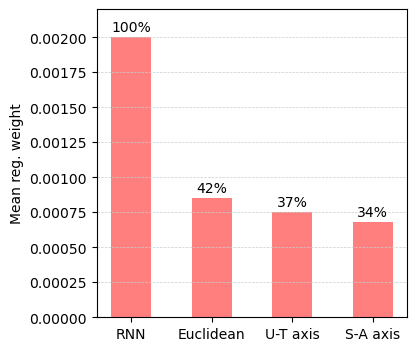

In [189]:
labels = ['RNN']
values = [0.002]
for ii in np.arange(n_maps):
    x = maps[ii][2] 
    mask = np.tril(np.ones(x.shape), k=-1).astype(bool)
    s = np.mean(x[mask==1])
    r = round(values[0]*s,5)
    labels.append(maps[ii][0])
    values.append(r)

print(labels)
print(values)
plt.figure(figsize=(4,4))
plt.bar(labels,values,width=0.5,color='red',alpha=0.5)
for ii in np.arange(len(values)):
    plt.text(ii, values[ii]+values[0]*0.02, str(int(100*values[ii]/values[0])) + '%', 
             verticalalignment='baseline', horizontalalignment='center')
plt.ylabel('Mean reg. weight')
plt.grid(axis='y',color=[0.8]*3,linestyle='--',linewidth=0.5)
plt.ylim(top=values[0]*1.1)

['S-A axis', 'RNN', 'Euclidean', 'U-T axis']
['0.002000', '0.000680', '0.001600', '0.001813']


(0.0, 0.0022)

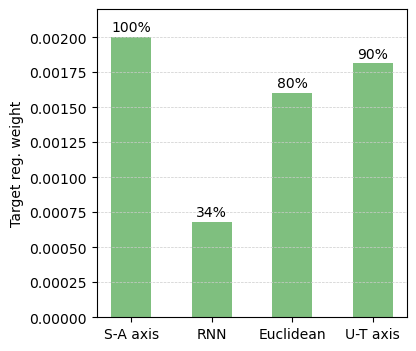

In [190]:
labels_sa_to = ['S-A axis']
values_sa_to = [0.002]
targ_val = values[labels.index('S-A axis')]
for ii in np.arange(len(values)):
    if labels[ii] == 'S-A axis':
        continue
    r = round(values_sa_to[0]*targ_val/values[ii],6)
    labels_sa_to.append(labels[ii])
    values_sa_to.append(r)

print(labels_sa_to)
print(["{:.6f}".format(num) for num in values_sa_to])
plt.figure(figsize=(4,4))
plt.bar(labels_sa_to,values_sa_to,width=0.5,color='green',alpha=0.5)
for ii in np.arange(len(values_sa_to)):
    plt.text(ii, values_sa_to[ii]+values_sa_to[0]*0.02, str(int(100*values_sa_to[ii]/values_sa_to[0])) + '%', 
             verticalalignment='baseline', horizontalalignment='center')
plt.ylabel('Target reg. weight')
plt.grid(axis='y',color=[0.8]*3,linestyle='--',linewidth=0.5)
plt.ylim(top=values_sa_to[0]*1.1)
